what we will Tune using optuna<br>
**Plan of Action**

1. Number of hidden layers
2. Neurons per layer
3. Number of epochs
4. Optimizer
5. Learning rate
6. Batch size
7. Dropout rate
8. Weight decay(lambda)

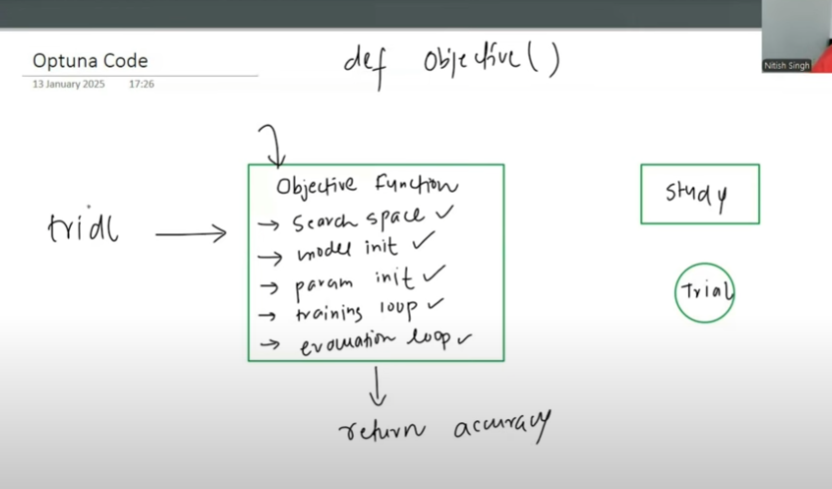

In [1]:
#importing some necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader

In [2]:
#device Agnostic code
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
#random seed for reproducibility
torch.manual_seed(42)

In [4]:
!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
 83% 57.0M/68.8M [00:00<00:00, 157MB/s]
100% 68.8M/68.8M [00:00<00:00, 118MB/s]


In [5]:
!unzip fashionmnist.zip

Archive:  fashionmnist.zip
  inflating: fashion-mnist_test.csv  
  inflating: fashion-mnist_train.csv  
  inflating: t10k-images-idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte  
  inflating: train-images-idx3-ubyte  
  inflating: train-labels-idx1-ubyte  


In [6]:
df=pd.read_csv('/content/fashion-mnist_train.csv')

In [7]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


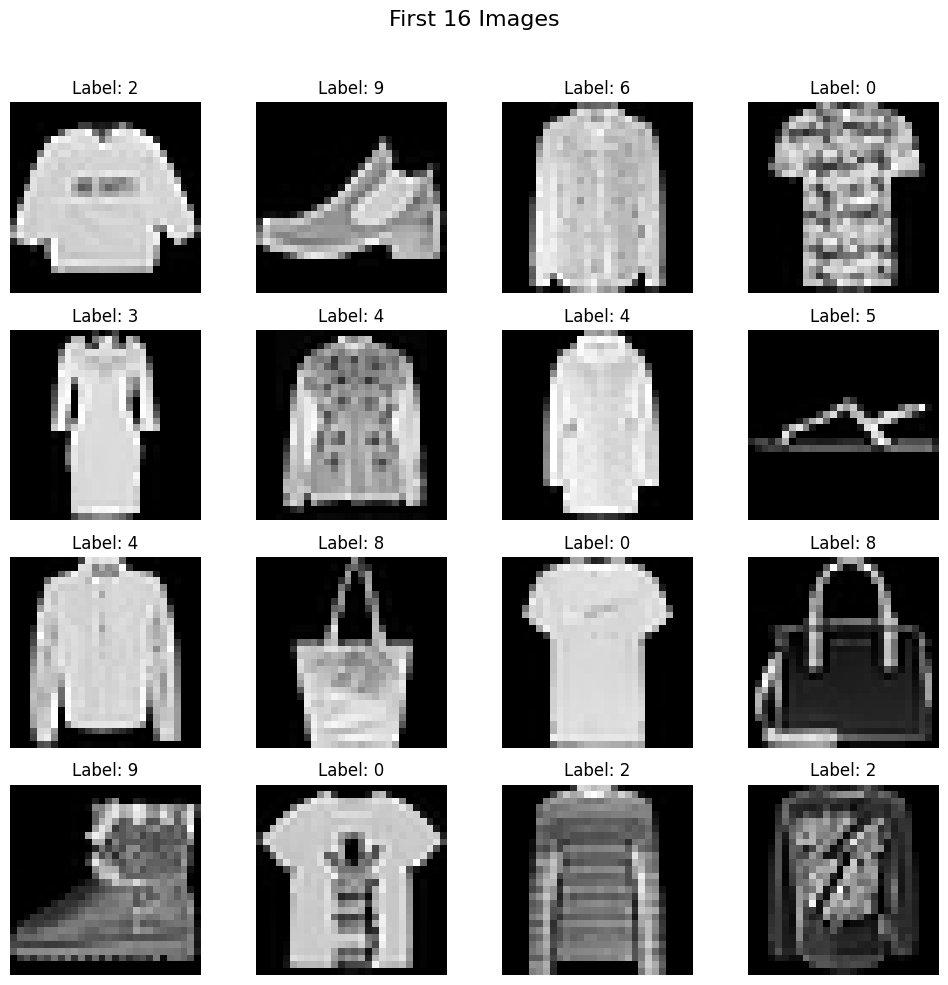

In [8]:
# Create a 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)  # Set a title for the whole figure

# Loop through the first 16 images and plot them
for i, ax in enumerate(axes.flat):  # Iterate over all 16 subplot axes
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Extract pixel values and reshape to 28x28
    ax.imshow(img, cmap='gray')  # Display the image in grayscale
    ax.axis('off')  # Remove the axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Display the label

# Adjust layout to fit the title properly
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()  # Display the plot

In [9]:
#generate x and y
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [10]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [11]:
#scaling our dataset
x_train=x_train/255.0
x_test=x_test/255.0

In [12]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [13]:
x_train.shape

(48000, 784)

In [14]:
#custom dataset
class CustomDataset(Dataset):

  def __init__(self,feature,labels):

    self.feature=torch.tensor(feature,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.feature)

  def __getitem__(self,index):

    return self.feature[index],self.labels[index]

In [15]:
train_dataset=CustomDataset(x_train,y_train)
test_dataset=CustomDataset(x_test,y_test)

In [16]:
len(train_dataset)

48000

In [17]:
len(test_dataset)

12000

In [18]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

#Define Model

In [19]:
class MyNN(nn.Module):

  def __init__(self,in_feature,out_feature,num_hiddenlayers,neurons_per_layer):

    super().__init__()

    layers=[]

    for i in range(num_hiddenlayers):
      layers.append(nn.Linear(in_features=in_feature,out_features=neurons_per_layer))
      layers.append(nn.BatchNorm1d(num_features=neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(p=0.3))
      in_feature=neurons_per_layer

    layers.append(nn.Linear(in_features=neurons_per_layer,out_features=out_feature))

    self.model=nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

#Optuna

In [20]:
def objective(trial):
  #next hyperparameter from search space
  num_hiddenlayers=trial.suggest_int('num_hiddenlayers',1,5)
  neurons_per_layer=trial.suggest_int('neurons_per_layer',8,128,step=8)
  #model init
  in_feature=784
  out_feature=10
  model=MyNN(in_feature,out_feature,num_hiddenlayers,neurons_per_layer)
  model.to(device)
  #params init
  learning_rate=0.01
  epochs=50

  #optimizer selection
  loss=nn.CrossEntropyLoss()
  optimizer=optim.SGD(model.parameters(),
                      lr=learning_rate,
                      weight_decay=1e-4)
  #Training loop
  for epoch in range(epochs):
    each_epoch_loss=0 #to calcluate loss of each epoch
    for batch_feature,batch_label in train_loader:
      #moving data to gpu
      batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
      #forward pass
      y_pred=model(batch_feature)
      #calculate loss
      train_loss=loss(y_pred,batch_label)
      #backpropagation
      optimizer.zero_grad()
      train_loss.backward()
      #update parameters
      optimizer.step()

  #Model Evaluation
  model.eval()
  total=0
  correct=0

  with torch.no_grad():
    for batch_feature,batch_label in test_loader:
      batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
      y_pred=model(batch_feature)
      _,predict=torch.max(y_pred,1)
      total+=batch_label.shape[0]
      correct+=(predict==batch_label).sum().item()

  accuracy=correct/total
  #return Accuracy
  return accuracy



In [21]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.8 MB/s eta 0:00:00


In [22]:
import optuna

In [23]:
study=optuna.create_study(direction='maximize')

[I 2025-02-18 04:40:58,208] A new study created in memory with name: no-name-ad5a337f-d80f-40d2-8b20-c092b9124061


In [24]:
study.optimize(objective,n_trials=10)

[I 2025-02-18 04:44:53,954] Trial 0 finished with value: 0.8933333333333333 and parameters: {'num_hiddenlayers': 4, 'neurons_per_layer': 128}. Best is trial 0 with value: 0.8933333333333333.
[I 2025-02-18 04:47:00,320] Trial 1 finished with value: 0.8844166666666666 and parameters: {'num_hiddenlayers': 1, 'neurons_per_layer': 72}. Best is trial 0 with value: 0.8933333333333333.
[I 2025-02-18 04:49:03,657] Trial 2 finished with value: 0.8779166666666667 and parameters: {'num_hiddenlayers': 1, 'neurons_per_layer': 56}. Best is trial 0 with value: 0.8933333333333333.
[I 2025-02-18 04:51:37,079] Trial 3 finished with value: 0.8919166666666667 and parameters: {'num_hiddenlayers': 2, 'neurons_per_layer': 104}. Best is trial 0 with value: 0.8933333333333333.
[I 2025-02-18 04:55:41,179] Trial 4 finished with value: 0.88725 and parameters: {'num_hiddenlayers': 5, 'neurons_per_layer': 112}. Best is trial 0 with value: 0.8933333333333333.
[I 2025-02-18 04:57:42,972] Trial 5 finished with value: 0

In [25]:
study.best_trial.value

0.8933333333333333

In [29]:
study.best_trial.params

{'num_hiddenlayers': 4, 'neurons_per_layer': 128}

#Optuna on More parameters

In [30]:
class MyNN(nn.Module):

  def __init__(self,in_feature,out_feature,num_hiddenlayers,neurons_per_layer,dropout_rate):

    super().__init__()

    layers=[]

    for i in range(num_hiddenlayers):
      layers.append(nn.Linear(in_features=in_feature,out_features=neurons_per_layer))
      layers.append(nn.BatchNorm1d(num_features=neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(p=dropout_rate))
      in_feature=neurons_per_layer

    layers.append(nn.Linear(in_features=neurons_per_layer,out_features=out_feature))

    self.model=nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

In [31]:
def objective(trial):
  #next hyperparameter from search space
  num_hiddenlayers=trial.suggest_int('num_hiddenlayers',1,5)
  neurons_per_layer=trial.suggest_int('neurons_per_layer',8,128,step=8)
  epochs=trial.suggest_int('epochs',10,50,step=10)
  learning_rate=trial.suggest_float('learning_rate',1e-5,1e-1,log=True)
  dropout_rate=trial.suggest_float('dropout_rate',0.1,0.5,step=0.1)
  batch_size=trial.suggest_categorical('batch_size',[16,32,64,128])
  optimizer_name=trial.suggest_categorical('optimizer_name',['Adam','SGD','RMSprop'])
  weight_decay=trial.suggest_float('weight_decay',1e-5,1e-3,log=True)



  #dataloader for batch size Tuning
  train_loader=DataLoader(
      train_dataset,
      batch_size=batch_size,
      shuffle=True
  )

  test_loader=DataLoader(
      test_dataset,
      batch_size=batch_size,
      shuffle=False
  )

  #model init
  in_feature=784
  out_feature=10
  model=MyNN(in_feature,out_feature,num_hiddenlayers,neurons_per_layer,dropout_rate)
  model.to(device)

  #optimizer selection
  loss=nn.CrossEntropyLoss()
  optimizer=optim.SGD(model.parameters(),
                      lr=learning_rate,
                      weight_decay=weight_decay)

  if optimizer_name=='Adam':

    optimizer=optim.Adam(model.parameters(),
                      lr=learning_rate,
                      weight_decay=weight_decay)
  elif optimizer_name=='SGD':
    optimizer=optim.SGD(model.parameters(),
                      lr=learning_rate,
                      weight_decay=weight_decay)
  else:
    optimizer=optim.RMSprop(model.parameters(),
                      lr=learning_rate,
                      weight_decay=weight_decay)
  #Training loop
  for epoch in range(epochs):
    each_epoch_loss=0 #to calcluate loss of each epoch
    for batch_feature,batch_label in train_loader:
      #moving data to gpu
      batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
      #forward pass
      y_pred=model(batch_feature)
      #calculate loss
      train_loss=loss(y_pred,batch_label)
      #backpropagation
      optimizer.zero_grad()
      train_loss.backward()
      #update parameters
      optimizer.step()

  #Model Evaluation
  model.eval()
  total=0
  correct=0

  with torch.no_grad():
    for batch_feature,batch_label in test_loader:
      batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
      y_pred=model(batch_feature)
      _,predict=torch.max(y_pred,1)
      total+=batch_label.shape[0]
      correct+=(predict==batch_label).sum().item()

  accuracy=correct/total
  #return Accuracy
  return accuracy

